# Ecuaciones de Poisson y Laplace — Fundamentos y Discretización

---

## 1. Contexto Físico

Muchos fenómenos de la física clásica se describen mediante campos escalares $V(x,y)$ que satisfacen una relación entre el campo y sus fuentes. Los dos casos más importantes son:

| Fenómeno | Campo $V$ | Fuente $f$ |
|---|---|---|
| Electrostática | Potencial eléctrico | Densidad de carga $\rho/\varepsilon_0$ |
| Conducción de calor | Temperatura | Fuentes/sumideros de calor |
| Flujo irrotacional | Función de corriente | Fuentes/sumideros de fluido |
| Gravedad newtoniana | Potencial gravitacional | Densidad de masa $4\pi G\rho$ |

En todos estos casos, el campo obedece la misma forma matemática.

---

## 2. El Operador Laplaciano

El **operador laplaciano** $\nabla^2$ mide la *curvatura promedio* de un campo escalar. En coordenadas cartesianas 2D:

$$\nabla^2 V = \frac{\partial^2 V}{\partial x^2} + \frac{\partial^2 V}{\partial y^2}$$

Intuitivamente: si $\nabla^2 V > 0$ en un punto, el campo es *cóncavo* allí (el valor en ese punto es menor que el promedio de sus vecinos). Si $\nabla^2 V < 0$, es *convexo*.

---

## 3. Ecuación de Laplace

Cuando **no hay fuentes** en el dominio, el campo satisface:

$$\boxed{\nabla^2 V = 0}$$

$$\frac{\partial^2 V}{\partial x^2} + \frac{\partial^2 V}{\partial y^2} = 0$$

### Interpretación física
Una función que satisface Laplace se llama **función armónica**. Su propiedad fundamental es que el valor en cualquier punto es exactamente igual al **promedio** de los valores en sus vecinos. Esto implica que:

- No tiene máximos ni mínimos en el interior del dominio.
- Los valores extremos siempre están en la frontera.
- El campo es "lo más suave posible" dado sus valores en la frontera.

**Ejemplos clásicos:** potencial electrostático en el vacío, temperatura en estado estacionario sin fuentes de calor, flujo potencial de un fluido ideal.

---

## 4. Ecuación de Poisson

Cuando **sí existen fuentes** distribuidas en el dominio, el campo satisface:

$$\boxed{\nabla^2 V = f(x,y)}$$

$$\frac{\partial^2 V}{\partial x^2} + \frac{\partial^2 V}{\partial y^2} = f(x,y)$$

donde $f(x,y)$ es el **término fuente** (o función forzante). La ecuación de Laplace es simplemente el caso particular $f = 0$.

### Interpretación física
El término fuente "rompe" la armonía del campo: en los puntos donde $f \neq 0$, el valor de $V$ ya no es el promedio de sus vecinos — hay una desviación forzada por la fuente local.

---

## 5. Condiciones de Contorno

La ecuación sola no tiene solución única — necesita condiciones en la **frontera** $\partial\Omega$ del dominio $\Omega$. Las más comunes son:

- **Dirichlet:** se fija el valor de $V$ en la frontera: $V\big|_{\partial\Omega} = g(x,y)$
- **Neumann:** se fija la derivada normal: $\dfrac{\partial V}{\partial n}\bigg|_{\partial\Omega} = g(x,y)$
- **Mixtas:** Dirichlet en unos bordes, Neumann en otros.

En todos los ejercicios de este notebook se usan **condiciones de Dirichlet**.

---

## 6. Discretización por Diferencias Finitas

### 6.1 La grilla

El dominio continuo $[x_0, x_f] \times [y_0, y_f]$ se reemplaza por un conjunto discreto de **nodos** $(x_j, y_i)$:

$$x_j = x_0 + j\,h, \quad j = 0, 1, \ldots, M \qquad h = \frac{x_f - x_0}{M}$$

$$y_i = y_0 + i\,k, \quad i = 0, 1, \ldots, N \qquad k = \frac{y_f - y_0}{N}$$

El valor desconocido en cada nodo se denota $V_{i,j} \approx V(x_j, y_i)$.

### 6.2 Aproximación de las derivadas

Usando la expansión de Taylor alrededor del nodo $(i,j)$:

$$V(x+h) = V + h\frac{\partial V}{\partial x} + \frac{h^2}{2}\frac{\partial^2 V}{\partial x^2} + \frac{h^3}{6}\frac{\partial^3 V}{\partial x^3} + \mathcal{O}(h^4)$$

$$V(x-h) = V - h\frac{\partial V}{\partial x} + \frac{h^2}{2}\frac{\partial^2 V}{\partial x^2} - \frac{h^3}{6}\frac{\partial^3 V}{\partial x^3} + \mathcal{O}(h^4)$$

Sumando ambas expresiones y despejando la segunda derivada:

$$\frac{\partial^2 V}{\partial x^2}\bigg|_{i,j} \approx \frac{V_{i,j+1} - 2V_{i,j} + V_{i,j-1}}{h^2} + \mathcal{O}(h^2)$$

Análogamente en $y$:

$$\frac{\partial^2 V}{\partial y^2}\bigg|_{i,j} \approx \frac{V_{i+1,j} - 2V_{i,j} + V_{i-1,j}}{k^2} + \mathcal{O}(k^2)$$

El error de truncación es de **orden 2** en ambos pasos: al reducir $h$ y $k$ a la mitad, el error cae a la cuarta parte.

### 6.3 El stencil de 5 puntos

Sustituyendo en $\nabla^2 V = f_{i,j}$:

$$\frac{V_{i,j+1} - 2V_{i,j} + V_{i,j-1}}{h^2} + \frac{V_{i+1,j} - 2V_{i,j} + V_{i-1,j}}{k^2} = f_{i,j}$$

Este patrón se llama **stencil de 5 puntos** porque involucra el nodo central y sus 4 vecinos inmediatos:

```
              V(i+1, j)
                  |
V(i, j-1) —— V(i, j) —— V(i, j+1)
                  |
              V(i-1, j)
```

### 6.4 Fórmula iterativa (despeje de $V_{i,j}$)

Multiplicando la ecuación discretizada por $h^2 k^2$ y despejando $V_{i,j}$:

$$\boxed{V_{i,j} = \frac{k^2\,(V_{i+1,j} + V_{i-1,j}) \;+\; h^2\,(V_{i,j+1} + V_{i,j-1}) \;-\; h^2 k^2\, f_{i,j}}{2\,(h^2 + k^2)}}$$

Para la ecuación de **Laplace** ($f = 0$):

$$V_{i,j} = \frac{k^2\,(V_{i+1,j} + V_{i-1,j}) + h^2\,(V_{i,j+1} + V_{i,j-1})}{2\,(h^2 + k^2)}$$

Si además la grilla es **uniforme** ($h = k$), la fórmula se simplifica al promedio simple de los 4 vecinos:

$$V_{i,j} = \frac{V_{i+1,j} + V_{i-1,j} + V_{i,j+1} + V_{i,j-1}}{4}$$

lo cual es la realización discreta exacta de la **propiedad del valor medio** de las funciones armónicas.

---

## 7. Método Iterativo de Jacobi

La fórmula anterior no puede resolverse directamente para todos los nodos a la vez (serían $M \times N$ ecuaciones acopladas). En su lugar se usa un esquema iterativo:

**Algoritmo:**
1. Inicializar $V^{(0)}$ con las condiciones de contorno en los bordes y cero en el interior.
2. En cada iteración $n$, actualizar **todos** los nodos interiores simultáneamente usando los valores del paso anterior:

$$V^{(n+1)}_{i,j} = \frac{k^2\,(V^{(n)}_{i+1,j} + V^{(n)}_{i-1,j}) + h^2\,(V^{(n)}_{i,j+1} + V^{(n)}_{i,j-1}) - h^2 k^2\, f_{i,j}}{2\,(h^2 + k^2)}$$

3. Calcular el **residuo** (cambio máximo entre iteraciones):

$$\delta^{(n)} = \max_{i,j}\left|V^{(n+1)}_{i,j} - V^{(n)}_{i,j}\right|$$

4. Si $\delta^{(n)} < \varepsilon_{\text{tol}}$, detener. Si no, regresar al paso 2.

El uso de $V^{(n)}$ (y no $V^{(n+1)}$ recién calculados) en el lado derecho es lo que define el método de **Jacobi**. Garantiza que todos los nodos se actualicen con información del mismo nivel temporal, lo cual facilita la implementación paralela.

---

## 8. Análisis del Error

El error numérico tiene dos componentes:

- **Error de truncación:** introducido al aproximar las derivadas. Es $\mathcal{O}(h^2 + k^2)$ — disminuye al refinar la grilla.
- **Error de iteración:** introducido al detener las iteraciones antes de la convergencia exacta. Se controla con la tolerancia $\varepsilon_{\text{tol}}$.

El error total observado $|V_{\text{num}} - V_{\text{ana}}|$ refleja ambas contribuciones. En los ejercicios de este notebook, con grilla $50\times50$ y tolerancia $10^{-6}$, el error dominante es el de truncación del orden de $10^{-4}$ a $10^{-3}$.

---

## 9. Resumen del Esquema Computacional

```
Dominio Ω = [x0,xf] × [y0,yf]
          ↓
    Grilla (M+1)×(N+1) nodos
    pasos h = Δx,  k = Δy
          ↓
    Inicializar T con CC en bordes
    Evaluar fuente f(xi, yj)
          ↓
    ┌─────────────────────────────┐
    │  JACOBI:                    │
    │  Para cada nodo interior:   │
    │    T_new[i,j] = stencil     │
    │  δ = max|T_new - T|         │
    │  T ← T_new                  │
    └──────────┬──────────────────┘
               │ δ < tol
               ↓
    Solución numérica V_num
          ↓
    Comparar con V_ana → |error|
```

  Visualizador: Poisson & Laplace — Diferencias Finitas

→ Ejercicio 1 — Poisson (ejercicio1.dat)
  ✓  Guardado: ejercicio1_resultado.png

→ Ejercicio 2 — Laplace (ejercicio2.dat)
  ✓  Guardado: ejercicio2_resultado.png

→ Ejercicio 3 — Poisson (ejercicio3.dat)
  ✓  Guardado: ejercicio3_resultado.png

→ Ejercicio 4 — Poisson (ejercicio4.dat)
  ✓  Guardado: ejercicio4_resultado.png

→ Figura resumen de errores
  ✓  Guardado: resumen_errores.png

  Mostrando gráficos... (cierra las ventanas para terminar)


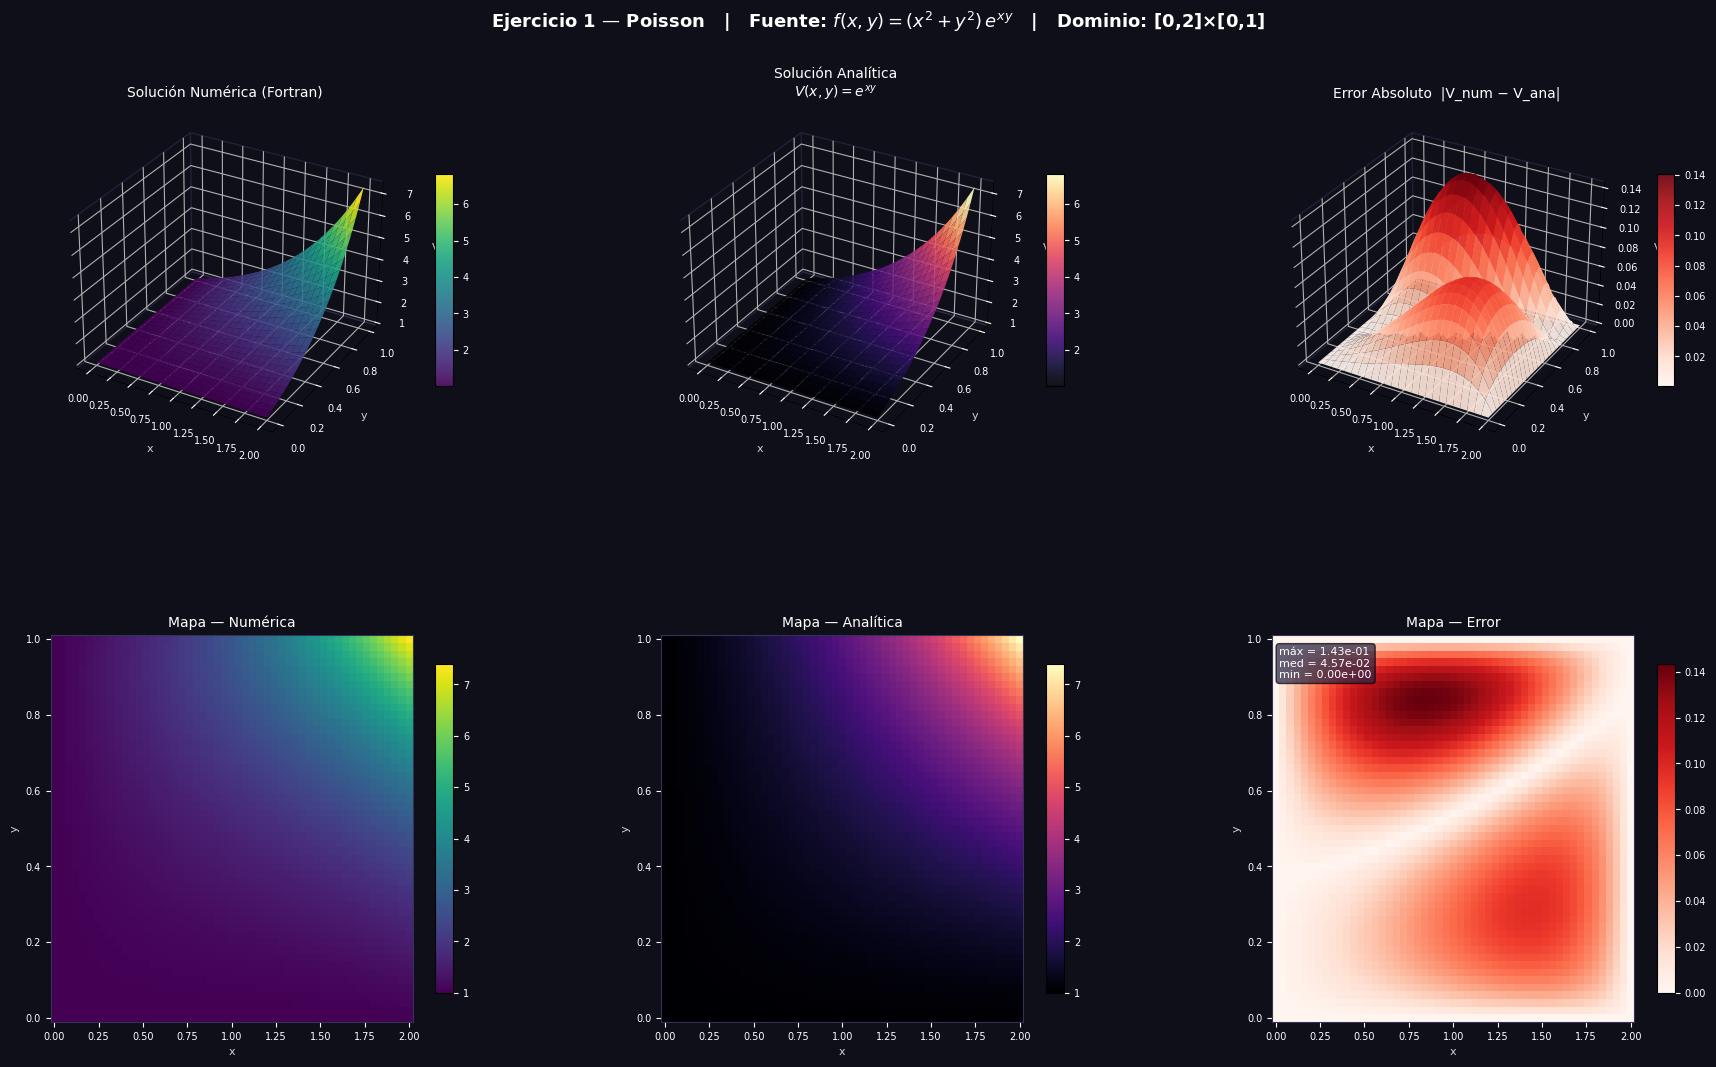

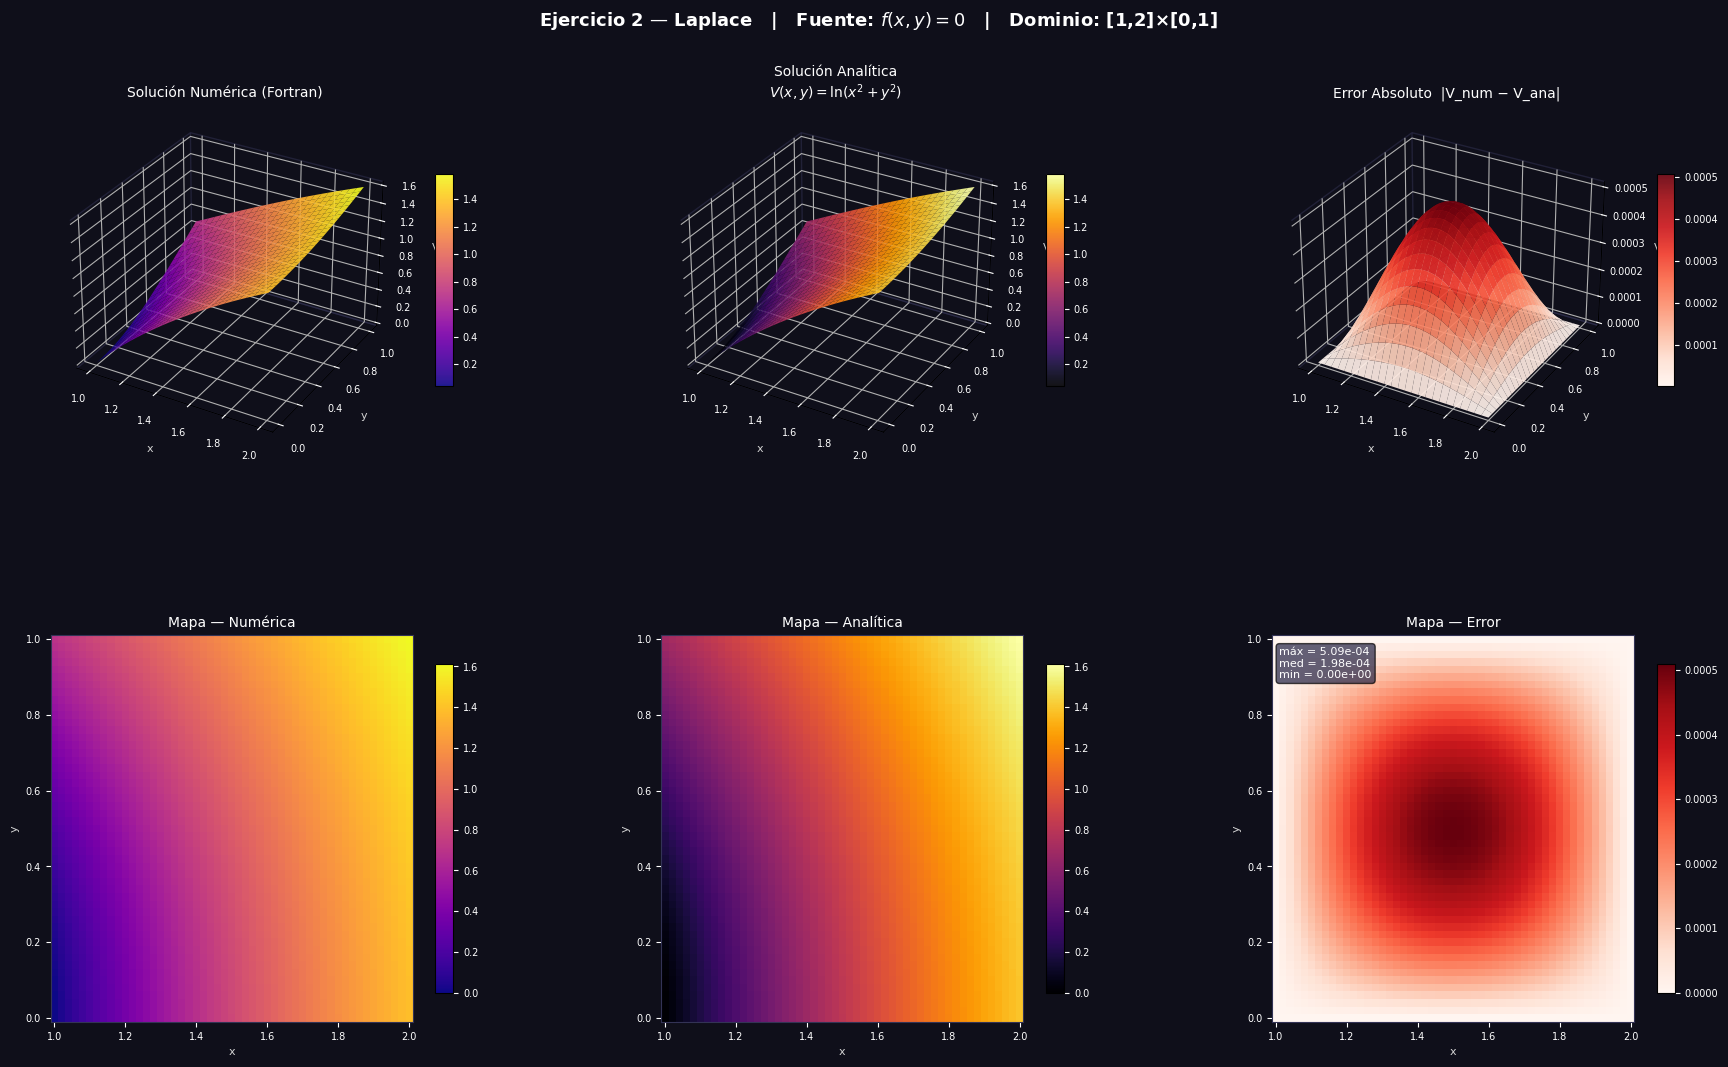

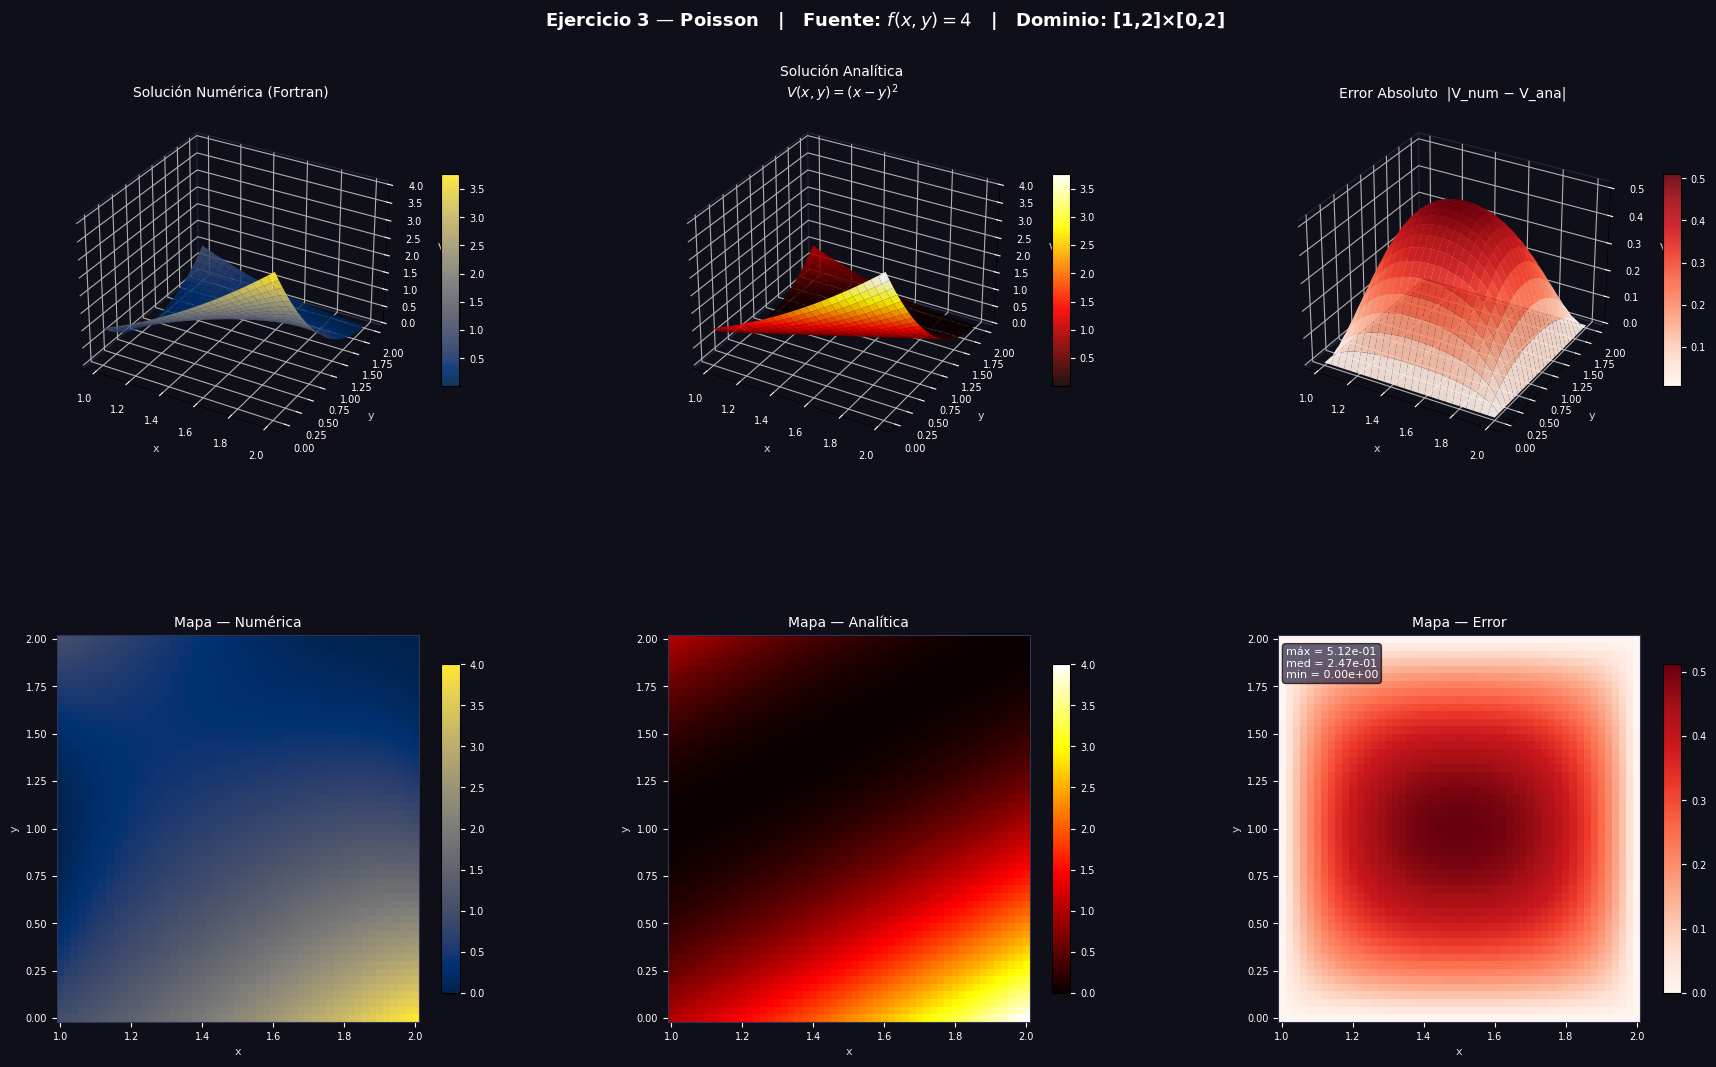

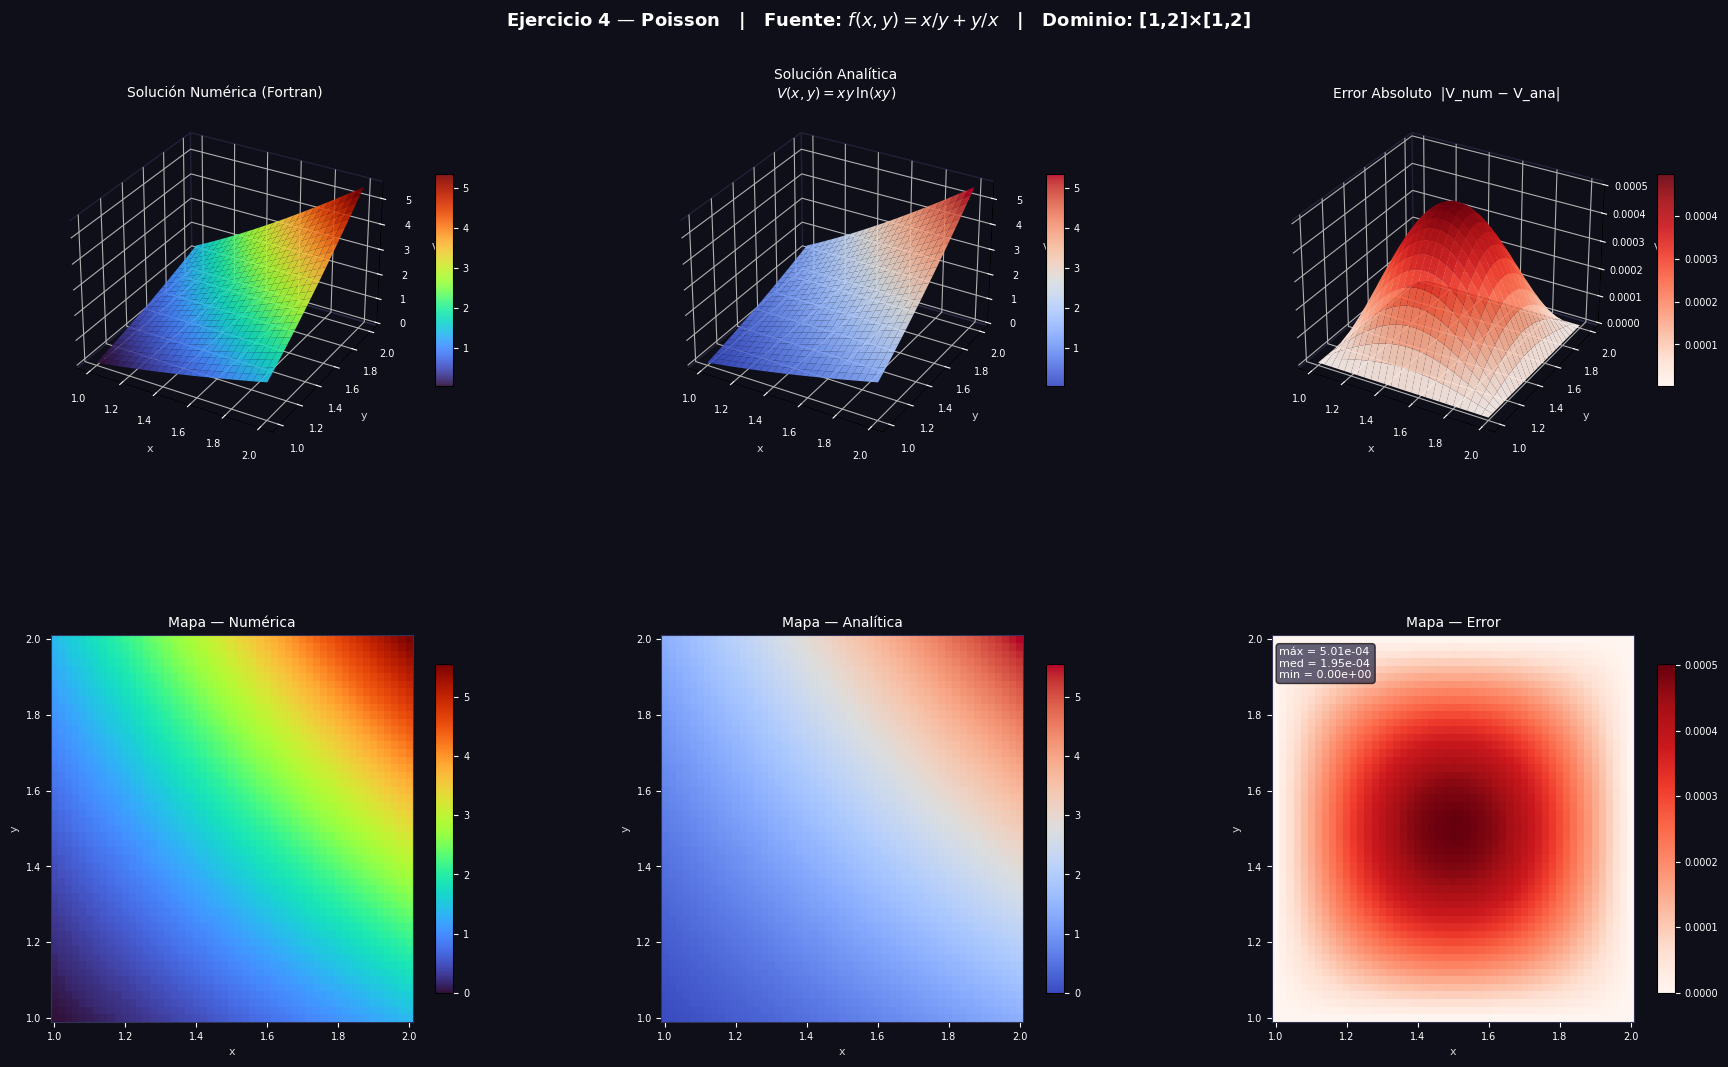

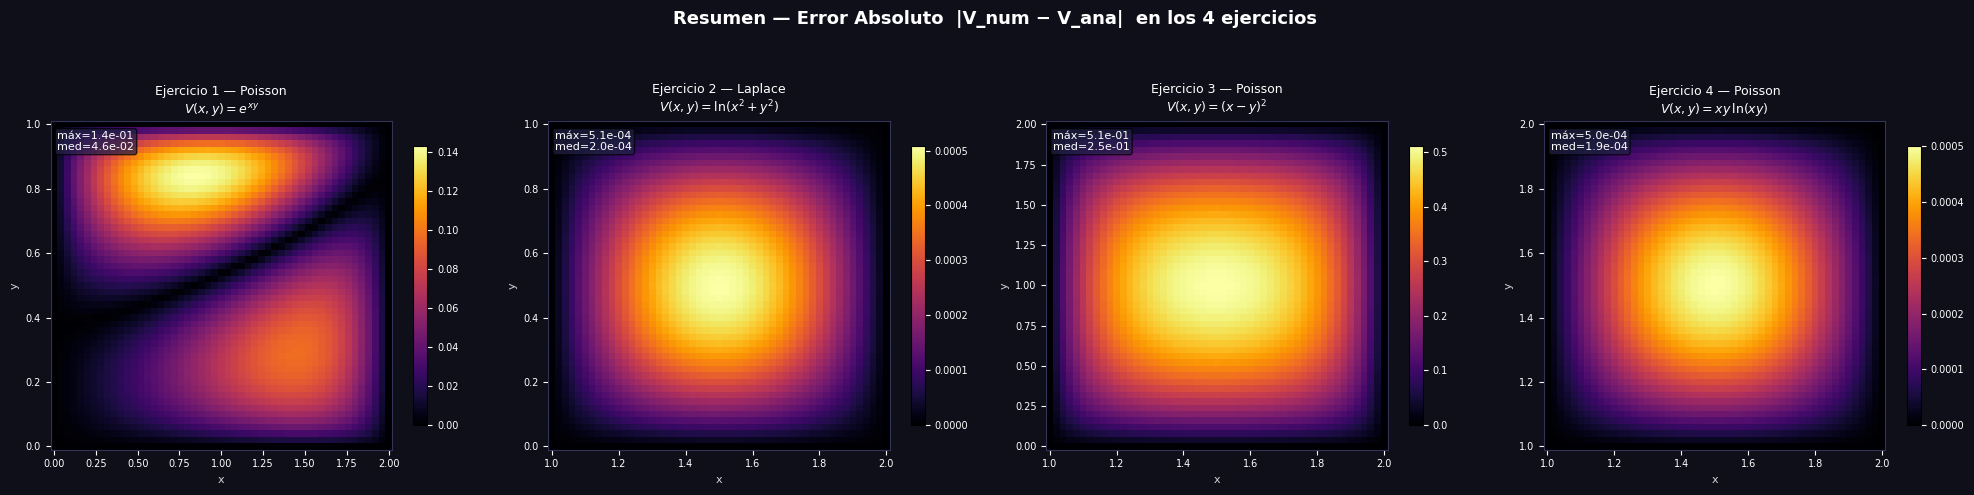

In [1]:
"""
====================================================================
  VISUALIZACIÓN DE RESULTADOS — Poisson & Laplace (Diferencias Finitas)
  Lee los archivos .dat generados por poisson_laplace.f90
  y produce gráficos 3D + mapas de calor comparativos.
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D
import os
import sys

# ─────────────────────────────────────────────
#  CONFIGURACIÓN DE EJERCICIOS
# ─────────────────────────────────────────────
EJERCICIOS = [
    {
        "archivo"  : "ejercicio1.dat",
        "titulo"   : "Ejercicio 1 — Poisson",
        "fuente"   : r"$f(x,y) = (x^2+y^2)\,e^{xy}$",
        "analitica": r"$V(x,y) = e^{xy}$",
        "dominio"  : "[0,2]×[0,1]",
        "cmap_num" : "viridis",
        "cmap_ana" : "magma",
    },
    {
        "archivo"  : "ejercicio2.dat",
        "titulo"   : "Ejercicio 2 — Laplace",
        "fuente"   : r"$f(x,y) = 0$",
        "analitica": r"$V(x,y) = \ln(x^2+y^2)$",
        "dominio"  : "[1,2]×[0,1]",
        "cmap_num" : "plasma",
        "cmap_ana" : "inferno",
    },
    {
        "archivo"  : "ejercicio3.dat",
        "titulo"   : "Ejercicio 3 — Poisson",
        "fuente"   : r"$f(x,y) = 4$",
        "analitica": r"$V(x,y) = (x-y)^2$",
        "dominio"  : "[1,2]×[0,2]",
        "cmap_num" : "cividis",
        "cmap_ana" : "hot",
    },
    {
        "archivo"  : "ejercicio4.dat",
        "titulo"   : "Ejercicio 4 — Poisson",
        "fuente"   : r"$f(x,y) = x/y + y/x$",
        "analitica": r"$V(x,y) = xy\,\ln(xy)$",
        "dominio"  : "[1,2]×[1,2]",
        "cmap_num" : "turbo",
        "cmap_ana" : "coolwarm",
    },
]


# ─────────────────────────────────────────────
#  LECTURA DE ARCHIVO .dat
# ─────────────────────────────────────────────
def leer_dat(archivo):
    """
    Lee el archivo .dat con columnas: x  y  V_num  V_ana  |error|
    Devuelve arrays 2D (grilla) para cada variable.
    """
    if not os.path.isfile(archivo):
        return None

    data = np.loadtxt(archivo, comments="#")
    x_flat   = data[:, 0]
    y_flat   = data[:, 1]
    num_flat = data[:, 2]
    ana_flat = data[:, 3]
    err_flat = data[:, 4]

    # Reconstruir grilla 2D a partir de valores únicos
    xs = np.unique(np.round(x_flat, 10))
    ys = np.unique(np.round(y_flat, 10))
    Nx, Ny = len(xs), len(ys)

    X   = x_flat.reshape(Ny, Nx)
    Y   = y_flat.reshape(Ny, Nx)
    NUM = num_flat.reshape(Ny, Nx)
    ANA = ana_flat.reshape(Ny, Nx)
    ERR = err_flat.reshape(Ny, Nx)

    return X, Y, NUM, ANA, ERR


# ─────────────────────────────────────────────
#  FIGURA POR EJERCICIO: 3D + heatmaps + error
# ─────────────────────────────────────────────
def graficar_ejercicio(ej, idx):
    datos = leer_dat(ej["archivo"])
    if datos is None:
        print(f"  ⚠  No se encontró '{ej['archivo']}' — omitiendo.")
        return

    X, Y, NUM, ANA, ERR = datos

    fig = plt.figure(figsize=(18, 11))
    fig.patch.set_facecolor("#0f0f1a")

    titulo_fig = (f"{ej['titulo']}   |   Fuente: {ej['fuente']}   |   "
                  f"Dominio: {ej['dominio']}")
    fig.suptitle(titulo_fig, color="white", fontsize=13, fontweight="bold", y=0.97)

    gs = gridspec.GridSpec(2, 3, figure=fig,
                           hspace=0.42, wspace=0.35,
                           top=0.90, bottom=0.05,
                           left=0.04, right=0.97)

    ax_cfg = dict(facecolor="#0f0f1a")

    # ── Fila superior: superficies 3D ──────────────────────────────────────
    def surf3d(pos, Z, cmap, label):
        ax = fig.add_subplot(pos, projection="3d", **ax_cfg)
        surf = ax.plot_surface(X, Y, Z, cmap=cmap,
                               edgecolor="none", alpha=0.92,
                               linewidth=0, antialiased=True)
        ax.set_facecolor("#0f0f1a")
        ax.tick_params(colors="white", labelsize=7)
        for pane in [ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane]:
            pane.fill = False
            pane.set_edgecolor("#333355")
        ax.set_xlabel("x", color="lightgray", fontsize=8, labelpad=4)
        ax.set_ylabel("y", color="lightgray", fontsize=8, labelpad=4)
        ax.set_zlabel("V", color="lightgray", fontsize=8, labelpad=4)
        ax.set_title(label, color="white", fontsize=10, pad=6)
        cb = fig.colorbar(surf, ax=ax, shrink=0.55, aspect=12, pad=0.08)
        cb.ax.yaxis.set_tick_params(color="white", labelsize=7)
        plt.setp(cb.ax.yaxis.get_ticklabels(), color="white")
        return ax

    surf3d(gs[0, 0], NUM, ej["cmap_num"], "Solución Numérica (Fortran)")
    surf3d(gs[0, 1], ANA, ej["cmap_ana"], f"Solución Analítica\n{ej['analitica']}")
    surf3d(gs[0, 2], ERR, "Reds",         "Error Absoluto  |V_num − V_ana|")

    # ── Fila inferior: mapas de calor 2D ───────────────────────────────────
    def heatmap(pos, Z, cmap, label):
        ax = fig.add_subplot(pos, **ax_cfg)
        im = ax.pcolormesh(X, Y, Z, cmap=cmap, shading="auto")
        ax.set_facecolor("#0f0f1a")
        ax.set_xlabel("x", color="lightgray", fontsize=8)
        ax.set_ylabel("y", color="lightgray", fontsize=8)
        ax.tick_params(colors="white", labelsize=7)
        ax.set_title(label, color="white", fontsize=10)
        for sp in ax.spines.values():
            sp.set_edgecolor("#333355")
        cb = fig.colorbar(im, ax=ax, shrink=0.85, aspect=18)
        cb.ax.yaxis.set_tick_params(color="white", labelsize=7)
        plt.setp(cb.ax.yaxis.get_ticklabels(), color="white")
        return ax

    heatmap(gs[1, 0], NUM, ej["cmap_num"], "Mapa — Numérica")
    heatmap(gs[1, 1], ANA, ej["cmap_ana"], "Mapa — Analítica")
    ax_err = heatmap(gs[1, 2], ERR, "Reds", "Mapa — Error")

    # Estadísticas de error sobre el mapa
    stats = (f"máx = {ERR.max():.2e}\n"
             f"med = {ERR.mean():.2e}\n"
             f"min = {ERR.min():.2e}")
    ax_err.text(0.02, 0.97, stats,
                transform=ax_err.transAxes,
                color="white", fontsize=8, va="top",
                bbox=dict(boxstyle="round,pad=0.3", fc="#222244", alpha=0.7))

    nombre_png = f"ejercicio{idx+1}_resultado.png"
    fig.savefig(nombre_png, dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    print(f"  ✓  Guardado: {nombre_png}")
    return fig


# ─────────────────────────────────────────────
#  FIGURA RESUMEN: los 4 errores en uno
# ─────────────────────────────────────────────
def graficar_resumen():
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.patch.set_facecolor("#0f0f1a")
    fig.suptitle("Resumen — Error Absoluto  |V_num − V_ana|  en los 4 ejercicios",
                 color="white", fontsize=13, fontweight="bold")

    for ax, ej, idx in zip(axes, EJERCICIOS, range(4)):
        datos = leer_dat(ej["archivo"])
        ax.set_facecolor("#0f0f1a")
        if datos is None:
            ax.text(0.5, 0.5, "Sin datos", color="white",
                    ha="center", va="center", transform=ax.transAxes)
            ax.set_title(ej["titulo"], color="white")
            continue

        X, Y, _, _, ERR = datos
        im = ax.pcolormesh(X, Y, ERR, cmap="inferno", shading="auto")
        ax.set_title(f"{ej['titulo']}\n{ej['analitica']}", color="white", fontsize=9)
        ax.set_xlabel("x", color="lightgray", fontsize=8)
        ax.set_ylabel("y", color="lightgray", fontsize=8)
        ax.tick_params(colors="white", labelsize=7)
        for sp in ax.spines.values():
            sp.set_edgecolor("#333355")
        cb = fig.colorbar(im, ax=ax, shrink=0.85)
        cb.ax.yaxis.set_tick_params(color="white", labelsize=7)
        plt.setp(cb.ax.yaxis.get_ticklabels(), color="white")
        ax.text(0.02, 0.97,
                f"máx={ERR.max():.1e}\nmed={ERR.mean():.1e}",
                transform=ax.transAxes, color="white", fontsize=8, va="top",
                bbox=dict(boxstyle="round,pad=0.2", fc="#222244", alpha=0.7))

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    fig.savefig("resumen_errores.png", dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    print("  ✓  Guardado: resumen_errores.png")
    return fig


# ─────────────────────────────────────────────
#  MAIN
# ─────────────────────────────────────────────
if __name__ == "__main__":
    print("=" * 55)
    print("  Visualizador: Poisson & Laplace — Diferencias Finitas")
    print("=" * 55)

    encontrados = [ej for ej in EJERCICIOS if os.path.isfile(ej["archivo"])]
    if not encontrados:
        print("\n  ⚠  No se encontró ningún archivo .dat en este directorio.")
        print("     Ejecuta primero el binario de Fortran:\n")
        print("       gfortran -O2 -o poisson_laplace poisson_laplace.f90")
        print("       ./poisson_laplace\n")
        sys.exit(1)

    figs = []
    for idx, ej in enumerate(EJERCICIOS):
        print(f"\n→ {ej['titulo']} ({ej['archivo']})")
        f = graficar_ejercicio(ej, idx)
        if f:
            figs.append(f)

    print("\n→ Figura resumen de errores")
    figs.append(graficar_resumen())

    print("\n  Mostrando gráficos... (cierra las ventanas para terminar)")
    plt.show()

  Visualizador de Rendimiento — Poisson & Laplace

→ Figura 1: Tiempo vs Malla (Python)
✓ Guardada: fig1_python_solo.png
→ Figura 2: Barras costo total (Python)
✓ Guardada: fig2_barras_python.png
→ Figura 3: Comparación Python vs Fortran
✓ Guardada: fig3_comparacion.png
→ Figura 4: Speedup


ZeroDivisionError: float division by zero

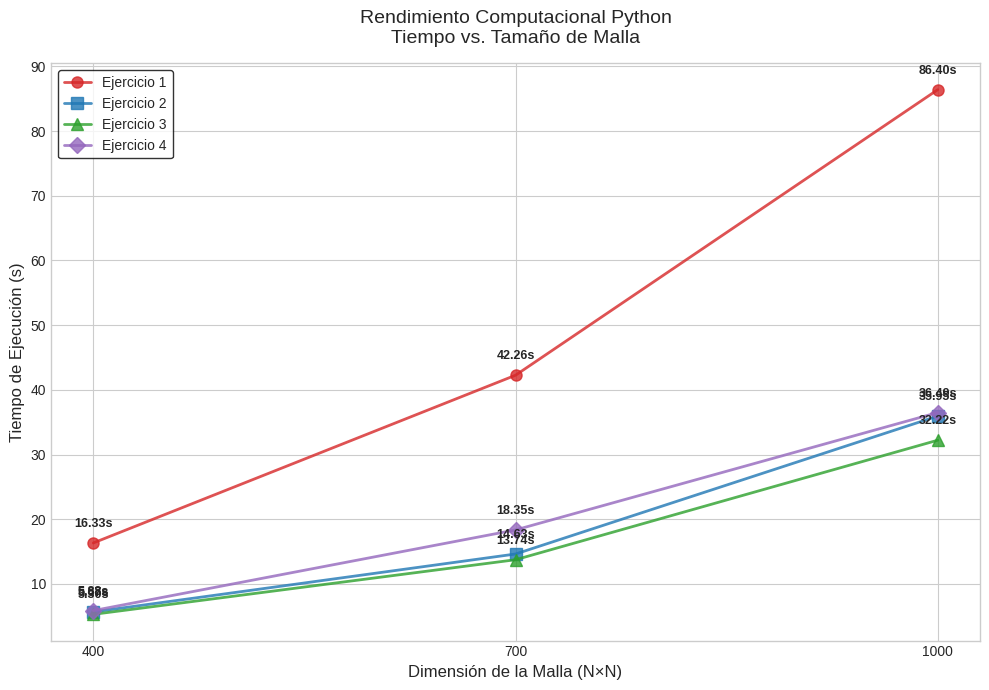

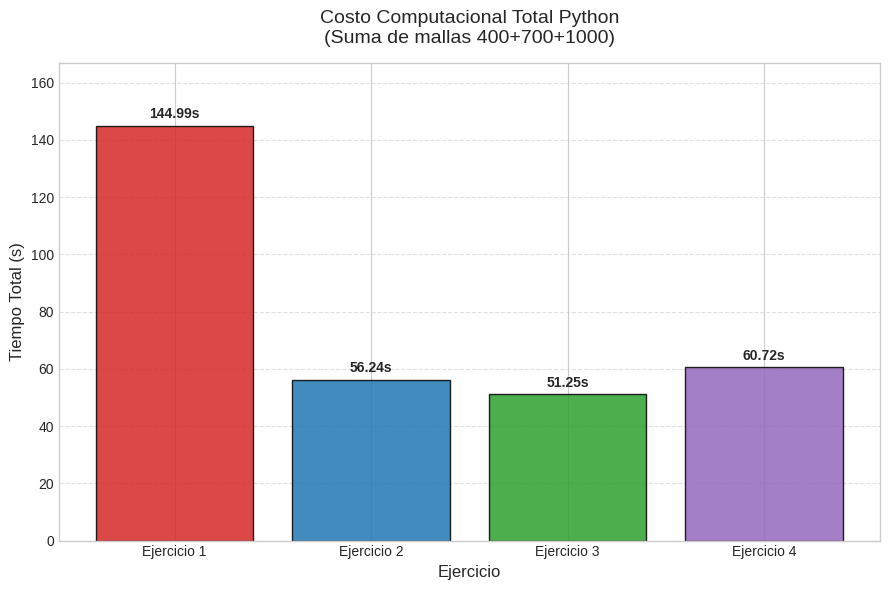

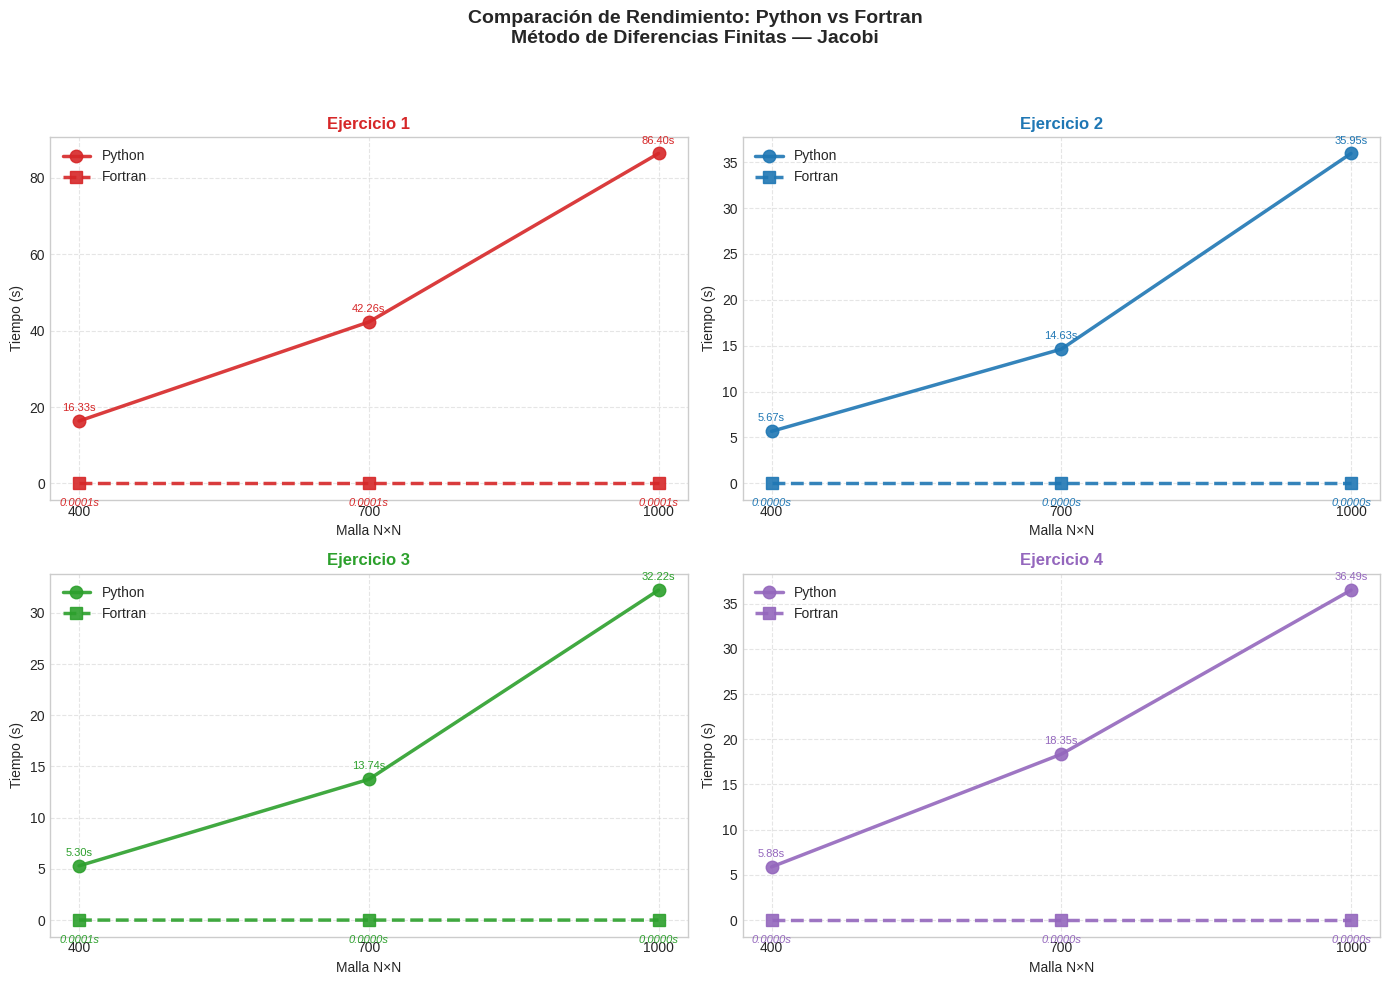

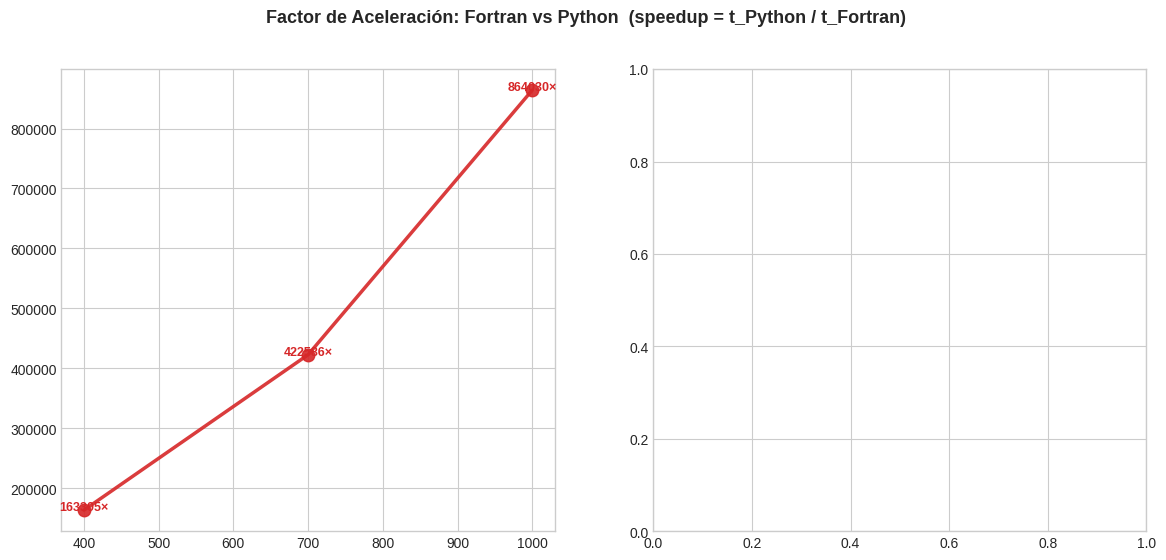

In [3]:
"""
====================================================================
  VISUALIZACIÓN DE RENDIMIENTO — Python vs Fortran
  Lee tiempos_fortran.dat generado por benchmark_tiempos.f90
  y reproduce + extiende las gráficas del notebook Mallas_tiempo.ipynb

  Uso:
      python graficar_tiempos.py

  Requisitos: numpy, matplotlib
====================================================================
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os, sys

# ─────────────────────────────────────────────────────────────────
#  Tiempos Python originales del notebook
# ─────────────────────────────────────────────────────────────────
MALLAS = np.array([400, 700, 1000])

PYTHON = {
    "Ejercicio 1": [16.3305, 42.2586, 86.4030],
    "Ejercicio 2": [ 5.6702, 14.6251, 35.9491],
    "Ejercicio 3": [ 5.2973, 13.7404, 32.2162],
    "Ejercicio 4": [ 5.8790, 18.3472, 36.4926],
}

COLORES   = ['#d62728', '#1f77b4', '#2ca02c', '#9467bd']
MARCADORES = ['o', 's', '^', 'D']
EJERCICIOS = list(PYTHON.keys())

# ─────────────────────────────────────────────────────────────────
#  Leer tiempos Fortran
# ─────────────────────────────────────────────────────────────────
def leer_fortran(archivo="tiempos_fortran.dat"):
    if not os.path.isfile(archivo):
        print(f"⚠  No se encontró '{archivo}'.")
        print("   Compila y ejecuta primero el benchmark de Fortran:")
        print("     gfortran -O2 -o benchmark benchmark_tiempos.f90")
        print("     ./benchmark")
        return None
    data = np.loadtxt(archivo, comments="#")
    # columnas: malla  ej1  ej2  ej3  ej4
    fortran = {}
    for k, nombre in enumerate(EJERCICIOS):
        fortran[nombre] = data[:, k+1].tolist()
    return fortran

# ─────────────────────────────────────────────────────────────────
#  FIGURA 1 — Tiempo vs Malla (Python solo, réplica del notebook)
# ─────────────────────────────────────────────────────────────────
def fig_python_solo():
    fig, ax = plt.subplots(figsize=(10, 7), dpi=100)
    plt.style.use('seaborn-v0_8-whitegrid')

    for i, (nombre, tiempos) in enumerate(PYTHON.items()):
        ax.plot(MALLAS, tiempos, label=nombre, color=COLORES[i],
                marker=MARCADORES[i], linestyle='-', linewidth=2,
                markersize=8, alpha=0.8)
        for x, y in zip(MALLAS, tiempos):
            ax.text(x, y + 2, f'{y:.2f}s', ha='center', va='bottom',
                    fontsize=9, fontweight='bold')

    ax.set_title('Rendimiento Computacional Python\nTiempo vs. Tamaño de Malla',
                 fontsize=14, pad=15)
    ax.set_xlabel('Dimensión de la Malla (N×N)', fontsize=12)
    ax.set_ylabel('Tiempo de Ejecución (s)', fontsize=12)
    ax.set_xticks(MALLAS)
    ax.legend(frameon=True, facecolor='white', edgecolor='black')
    plt.tight_layout()
    fig.savefig("fig1_python_solo.png", dpi=150, bbox_inches='tight')
    print("✓ Guardada: fig1_python_solo.png")
    return fig

# ─────────────────────────────────────────────────────────────────
#  FIGURA 2 — Barras de costo total Python (réplica del notebook)
# ─────────────────────────────────────────────────────────────────
def fig_barras_python():
    totales = [sum(t) for t in PYTHON.values()]

    fig, ax = plt.subplots(figsize=(9, 6), dpi=100)
    plt.style.use('seaborn-v0_8-whitegrid')
    barras = ax.bar(EJERCICIOS, totales, color=COLORES, alpha=0.85, edgecolor='black')

    for b in barras:
        y = b.get_height()
        ax.text(b.get_x() + b.get_width()/2, y + 1.5,
                f'{y:.2f}s', ha='center', va='bottom',
                fontweight='bold', fontsize=10)

    ax.set_title('Costo Computacional Total Python\n(Suma de mallas 400+700+1000)',
                 fontsize=14, pad=15)
    ax.set_ylabel('Tiempo Total (s)', fontsize=12)
    ax.set_xlabel('Ejercicio', fontsize=12)
    ax.set_ylim(0, max(totales) * 1.15)
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    fig.savefig("fig2_barras_python.png", dpi=150, bbox_inches='tight')
    print("✓ Guardada: fig2_barras_python.png")
    return fig

# ─────────────────────────────────────────────────────────────────
#  FIGURA 3 — Comparación Python vs Fortran (líneas)
# ─────────────────────────────────────────────────────────────────
def fig_comparacion(fortran):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=100)
    fig.suptitle('Comparación de Rendimiento: Python vs Fortran\n'
                 'Método de Diferencias Finitas — Jacobi', fontsize=14, fontweight='bold')
    axes = axes.flatten()

    for i, nombre in enumerate(EJERCICIOS):
        ax = axes[i]
        py = PYTHON[nombre]
        fo = fortran[nombre]

        ax.plot(MALLAS, py, color=COLORES[i], marker='o', linestyle='-',
                linewidth=2.5, markersize=9, label='Python', alpha=0.9)
        ax.plot(MALLAS, fo, color=COLORES[i], marker='s', linestyle='--',
                linewidth=2.5, markersize=9, label='Fortran', alpha=0.9)

        # Etiquetas
        for x, y in zip(MALLAS, py):
            ax.text(x, y + max(py)*0.03, f'{y:.2f}s', ha='center',
                    fontsize=8, color=COLORES[i])
        for x, y in zip(MALLAS, fo):
            ax.text(x, y - max(py)*0.07, f'{y:.4f}s', ha='center',
                    fontsize=8, color=COLORES[i], style='italic')

        ax.set_title(nombre, fontsize=12, fontweight='bold', color=COLORES[i])
        ax.set_xlabel('Malla N×N', fontsize=10)
        ax.set_ylabel('Tiempo (s)', fontsize=10)
        ax.set_xticks(MALLAS)
        ax.legend(fontsize=10)
        ax.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout(rect=[0, 0, 1, 0.94])
    fig.savefig("fig3_comparacion.png", dpi=150, bbox_inches='tight')
    print("✓ Guardada: fig3_comparacion.png")
    return fig

# ─────────────────────────────────────────────────────────────────
#  FIGURA 4 — Speedup Fortran / Python
# ─────────────────────────────────────────────────────────────────
def fig_speedup(fortran):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=100)
    fig.suptitle('Factor de Aceleración: Fortran vs Python  (speedup = t_Python / t_Fortran)',
                 fontsize=13, fontweight='bold')

    # — Panel izquierdo: speedup por malla para cada ejercicio —
    ax = axes[0]
    for i, nombre in enumerate(EJERCICIOS):
        speedup = [p/f for p, f in zip(PYTHON[nombre], fortran[nombre])]
        ax.plot(MALLAS, speedup, color=COLORES[i], marker=MARCADORES[i],
                linewidth=2.5, markersize=9, label=nombre, alpha=0.9)
        for x, y in zip(MALLAS, speedup):
            ax.text(x, y + 0.5, f'{y:.0f}×', ha='center', fontsize=9,
                    fontweight='bold', color=COLORES[i])

    ax.axhline(1, color='gray', linestyle=':', linewidth=1.5, label='Igual velocidad')
    ax.set_title('Speedup por tamaño de malla', fontsize=11)
    ax.set_xlabel('Malla N×N', fontsize=10)
    ax.set_ylabel('Speedup (veces más rápido)', fontsize=10)
    ax.set_xticks(MALLAS)
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.5)

    # — Panel derecho: barras de costo total Python vs Fortran —
    ax2 = axes[1]
    totales_py = [sum(PYTHON[n])    for n in EJERCICIOS]
    totales_fo = [sum(fortran[n])   for n in EJERCICIOS]

    x = np.arange(len(EJERCICIOS))
    w = 0.35
    b1 = ax2.bar(x - w/2, totales_py, w, label='Python', color=COLORES,
                 alpha=0.75, edgecolor='black')
    b2 = ax2.bar(x + w/2, totales_fo, w, label='Fortran',
                 color=[c + '99' for c in ['#d62728','#1f77b4','#2ca02c','#9467bd']],
                 alpha=0.95, edgecolor='black', hatch='//')

    for b in b1:
        ax2.text(b.get_x()+b.get_width()/2, b.get_height()+1,
                 f'{b.get_height():.1f}s', ha='center', fontsize=8, fontweight='bold')
    for b in b2:
        ax2.text(b.get_x()+b.get_width()/2, b.get_height()+0.2,
                 f'{b.get_height():.3f}s', ha='center', fontsize=8,
                 fontweight='bold', style='italic')

    ax2.set_title('Costo total acumulado (400+700+1000)', fontsize=11)
    ax2.set_ylabel('Tiempo Total (s)', fontsize=10)
    ax2.set_xticks(x)
    ax2.set_xticklabels([f'Ej{i+1}' for i in range(4)], fontsize=10)
    ax2.legend(fontsize=10)
    ax2.grid(axis='y', linestyle='--', alpha=0.5)

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    fig.savefig("fig4_speedup.png", dpi=150, bbox_inches='tight')
    print("✓ Guardada: fig4_speedup.png")
    return fig

# ─────────────────────────────────────────────────────────────────
#  FIGURA 5 — Escalado: crecimiento con el tamaño de malla
# ─────────────────────────────────────────────────────────────────
def fig_escalado(fortran):
    fig, ax = plt.subplots(figsize=(9, 6), dpi=100)
    ax.set_title('Escalado computacional: t vs N² (puntos de la malla)',
                 fontsize=13, fontweight='bold')

    n2 = MALLAS**2   # número total de puntos

    for i, nombre in enumerate(EJERCICIOS):
        py = PYTHON[nombre]
        fo = fortran[nombre]
        ax.plot(n2, py, color=COLORES[i], marker='o', linestyle='-',
                linewidth=2, markersize=8, label=f'{nombre} — Python', alpha=0.85)
        ax.plot(n2, fo, color=COLORES[i], marker='s', linestyle='--',
                linewidth=2, markersize=8, label=f'{nombre} — Fortran', alpha=0.85)

    ax.set_xlabel('Número de nodos (N²)', fontsize=11)
    ax.set_ylabel('Tiempo (s)', fontsize=11)
    ax.set_xticks(n2)
    ax.set_xticklabels([f'{int(v/1e6):.2f}M\n({int(np.sqrt(v))}²)' for v in n2])
    ax.legend(fontsize=8, ncol=2, loc='upper left')
    ax.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    fig.savefig("fig5_escalado.png", dpi=150, bbox_inches='tight')
    print("✓ Guardada: fig5_escalado.png")
    return fig

# ─────────────────────────────────────────────────────────────────
#  TABLA RESUMEN en consola
# ─────────────────────────────────────────────────────────────────
def tabla_consola(fortran):
    print("\n" + "="*70)
    print("  RESUMEN — Speedup Fortran vs Python")
    print("="*70)
    print(f"{'Ejercicio':<14}", end="")
    for m in MALLAS:
        print(f"  {m}×{m:4d}", end="")
    print(f"  {'Total':>8}  {'Speedup medio':>14}")
    print("-"*70)
    for nombre in EJERCICIOS:
        py = PYTHON[nombre]
        fo = fortran[nombre]
        speedups = [p/f for p, f in zip(py, fo)]
        sp_medio = np.mean(speedups)
        print(f"{nombre:<14}", end="")
        for s in speedups:
            print(f"  {s:7.1f}×", end="")
        print(f"  {sum(py):7.2f}s  {sp_medio:>12.1f}×")
    print("="*70)

# ─────────────────────────────────────────────────────────────────
#  MAIN
# ─────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    print("="*55)
    print("  Visualizador de Rendimiento — Poisson & Laplace")
    print("="*55)

    fortran = leer_fortran("tiempos_fortran.dat")

    # Figuras que solo necesitan datos Python (réplicas del notebook)
    print("\n→ Figura 1: Tiempo vs Malla (Python)")
    fig_python_solo()

    print("→ Figura 2: Barras costo total (Python)")
    fig_barras_python()

    if fortran is None:
        print("\n⚠  Sin datos Fortran — mostrando solo gráficas Python.")
        plt.show()
        sys.exit(0)

    # Figuras comparativas Python vs Fortran
    print("→ Figura 3: Comparación Python vs Fortran")
    fig_comparacion(fortran)

    print("→ Figura 4: Speedup")
    fig_speedup(fortran)

    print("→ Figura 5: Escalado con N²")
    fig_escalado(fortran)

    tabla_consola(fortran)

    print("\n  Mostrando gráficos...")
    plt.show()